# XY Plane MSD Analysis

参考 `MSD_each.ipynb` 的链筛选、dominant cluster 判定和 log-log 拟合画图风格，计算每条链 COM 在 xy 平面内的 MSD：

$$MSD_{xy}(\Delta t)=\langle \Delta x^2 + \Delta y^2 \rangle$$

图和导出的统计数据使用 `ns` 与 `nm^2`：时间保持 ns，MSD 由 A^2 转为 nm^2。所有结果写入同级目录下的 `MSD_xy_results/`。


In [11]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

ARIAL_TTF_PATH = Path("/data/jychen/package/Arial/arial.ttf")
USE_ARIAL_TTF = ARIAL_TTF_PATH.exists()

_PUB_FONT_NAME = None


def load_pub_font():
    """
    优先加载指定 Arial.ttf；如果当前机器没有该文件，则回退到系统字体名。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        fm.fontManager.addfont(str(ARIAL_TTF_PATH))
        _PUB_FONT_NAME = fm.FontProperties(fname=str(ARIAL_TTF_PATH)).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}

FIG_PRESETS = {
    "single_small": ("single", 60),
    "single_short": ("single", 70),
    "single_medium": ("single", 75),
    "double_short": ("double", 70),
    "double_medium": ("double", 100),
    "double_large": ("double", 140),
}

_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()

    base = {
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,
        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,
        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)))
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs,
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


set_pub_style()


Using font: Arial


In [12]:
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, NullLocator
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import linregress

try:
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import capped_distance
    HAS_MDA = True
    MDA_IMPORT_ERROR = None
except Exception as exc:
    HAS_MDA = False
    MDA_IMPORT_ERROR = exc

# ===================== 路径与运行参数 =====================
# 结果统一保存到这个文件夹, 不和原始 3D MSD 结果混在一起。
_CANDIDATE_DIRS = [
    Path.cwd(),
    Path.cwd() / "Analysis/MSD/MSD_each",
    Path("/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/MSD/MSD_each"),
]
for candidate in _CANDIDATE_DIRS:
    if (candidate / "MSD_each.ipynb").exists():
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    NOTEBOOK_DIR = Path.cwd().resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "MSD_xy_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RECOMPUTE = False
COLOR_MAP = "turbo"
FIG_PRESET = "double_short"
AVERAGE_COLOR = "#E64B35"

# 原始轨迹单位是 A 和 ps；这里统一把输出/拟合单位转成 nm 和 ns。
A2_TO_NM2 = 0.01
LINEAR_X_MAX_NS = 1000.0

COMMON_PARAMS = {
    "RESIDUES_PER_CHAIN": 140,
    "BB_SELECTION_STR": "name BB",
    "END_FRAME": -1,
    "STRIDE": 1,
    "CLUSTER_DIST_CUTOFF": 8.0,
    "MAX_LAG_RATIO": 0.9,
    "FIT_START_NS": 10.0,
    "FIT_END_NS": 100.0,
}

SCENARIO_COLORS = {
    "IDP_SOLV": "#4C78A8",
    "HELIX_SOLV": "#F58518",
    "IDP_MEM": "#54A24B",
    "HELIX_MEM": "#B279A2",
}

DATASETS = [
    {
        "name": "IDP_SOLV",
        "title": r"$\text{IDP}_{50}$",
        "color": SCENARIO_COLORS["IDP_SOLV"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {**COMMON_PARAMS, "ANALYSIS_CHAIN_RANGE": (0, None), "START_FRAME": 10000},
    },
    {
        "name": "HELIX_SOLV",
        "title": r"$\text{Hel}_{50}$",
        "color": SCENARIO_COLORS["HELIX_SOLV"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {**COMMON_PARAMS, "ANALYSIS_CHAIN_RANGE": (0, None), "START_FRAME": 10000},
    },
    {
        "name": "IDP_MEM",
        "title": r"$\text{IDP}_{50}$-Mem",
        "color": SCENARIO_COLORS["IDP_MEM"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {**COMMON_PARAMS, "ANALYSIS_CHAIN_RANGE": (0, None), "START_FRAME": 0},
    },
    {
        "name": "HELIX_MEM",
        "title": r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem",
        "color": SCENARIO_COLORS["HELIX_MEM"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {**COMMON_PARAMS, "ANALYSIS_CHAIN_RANGE": (-40, None), "START_FRAME": 10000},
    },
]

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"XY MSD output dir: {OUTPUT_DIR}")


Notebook dir: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/MSD/MSD_each
XY MSD output dir: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/MSD/MSD_each/MSD_xy_results


In [13]:
def process_single_replicate(args):
    rep_id, top_file, traj_file, dataset = args
    params = dataset["params"]

    if not HAS_MDA:
        return None, f"MDAnalysis unavailable: {MDA_IMPORT_ERROR}"

    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as exc:
        return None, f"{os.path.basename(traj_file)}: {exc}"

    protein = u.select_atoms("protein")
    n_chains = len(protein.residues) // params["RESIDUES_PER_CHAIN"]
    if n_chains == 0:
        return None, f"{os.path.basename(traj_file)}: no protein chains detected."

    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(params["BB_SELECTION_STR"])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[
        params["START_FRAME"] : params["END_FRAME"] : params["STRIDE"]
    ]
    n_frames = len(traj_slice)
    if n_frames < 2:
        return None, f"{os.path.basename(traj_file)}: not enough frames after slicing."

    all_coms = np.zeros((n_frames, n_chains, 3), dtype=np.float32)
    start_c, end_c = params["ANALYSIS_CHAIN_RANGE"]
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    for frame_idx, ts in enumerate(traj_slice):
        all_coms[frame_idx] = protein.positions.reshape(n_chains, -1, 3).mean(axis=1)

        pairs = capped_distance(
            bb_atoms.positions,
            bb_atoms.positions,
            max_cutoff=params["CLUSTER_DIST_CUTOFF"],
            box=ts.dimensions,
            return_distances=False,
        )
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]

        if len(c_pairs) > 0:
            rows = np.concatenate([c_pairs[:, 0], c_pairs[:, 1]])
            cols = np.concatenate([c_pairs[:, 1], c_pairs[:, 0]])
            data = np.ones(len(rows), dtype=np.int8)
            adj = csr_matrix((data, (rows, cols)), shape=(n_chains, n_chains))
        else:
            adj = csr_matrix((n_chains, n_chains), dtype=np.int8)

        n_comp, labels = connected_components(adj, directed=False)
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= labels == max_label
        else:
            valid_mask[:] = False
            break

    final_indices = np.where(valid_mask)[0]
    if len(final_indices) == 0:
        return None, f"{os.path.basename(traj_file)}: no chains remained in the dominant cluster."

    valid_coms_xy = all_coms[:, final_indices, :2]
    max_lag = min(int(n_frames * params["MAX_LAG_RATIO"]), n_frames - 1)
    if max_lag < 1:
        return None, f"{os.path.basename(traj_file)}: max lag is smaller than 1."

    # 原始坐标单位为 A，所以这里先得到 A^2；后续统一转换成 nm^2 输出/拟合。
    msd_matrix_a2 = np.zeros((max_lag, len(final_indices)), dtype=np.float32)
    for lag in range(1, max_lag + 1):
        diff_xy = valid_coms_xy[lag:] - valid_coms_xy[:-lag]
        msd_matrix_a2[lag - 1] = np.mean(np.sum(diff_xy * diff_xy, axis=2), axis=0)

    time_ns = (
        np.arange(1, max_lag + 1, dtype=np.float32)
        * u.trajectory.dt
        * params["STRIDE"]
        / 1000.0
    )
    return {
        "msd_a2": msd_matrix_a2,
        "time_ns": time_ns,
        "count": len(final_indices),
        "file": os.path.basename(traj_file),
    }, None


def fit_power_law(time_ns, mean_msd_nm2, fit_start_ns, fit_end_ns):
    fit_idx = (time_ns >= fit_start_ns) & (time_ns <= fit_end_ns) & (mean_msd_nm2 > 0)
    if np.count_nonzero(fit_idx) < 2:
        return {
            "alpha": np.nan,
            "K_ns": np.nan,
            "rvalue": np.nan,
            "fit_idx": fit_idx,
        }

    res_fit = linregress(np.log(time_ns[fit_idx]), np.log(mean_msd_nm2[fit_idx]))
    return {
        "alpha": res_fit.slope,
        "K_ns": np.exp(res_fit.intercept),
        "rvalue": res_fit.rvalue,
        "fit_idx": fit_idx,
    }


def save_average_csv(path, time_ns, mean_msd_nm2, sem_msd_nm2):
    data = np.column_stack([time_ns, mean_msd_nm2, sem_msd_nm2])
    np.savetxt(
        path,
        data,
        delimiter=",",
        header="time_ns,mean_xy_msd_nm2,sem_xy_msd_nm2",
        comments="",
    )


def write_fit_summary(path, dataset, result):
    fit = result["fit"]
    lines = [
        f"dataset={dataset['name']}",
        f"title={dataset['title']}",
        f"n_chains={result['msd_matrix_nm2'].shape[1]}",
        f"fit_start_ns={dataset['params']['FIT_START_NS']}",
        f"fit_end_ns={dataset['params']['FIT_END_NS']}",
        f"alpha={fit['alpha']:.8g}",
        f"K_nm2_per_ns_alpha={fit['K_ns']:.8g}",
        f"r_value={fit['rvalue']:.8g}",
    ]
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


def load_or_compute_raw_dataset(dataset):
    cache_file = OUTPUT_DIR / f"{dataset['name']}_xy_msd_data.npz"

    if cache_file.exists() and not FORCE_RECOMPUTE:
        cache = np.load(cache_file, allow_pickle=True)
        print(f"[缓存] 读取 A^2/ns 原始缓存: {cache_file.name}")
        combined_msd_a2 = cache["msd_matrix"]
        ref_time_ns = cache["time_ns"]
        counts_per_replicate = cache["counts_per_replicate"]
        replicate_files = cache["replicate_files"].astype(str).tolist()
        return combined_msd_a2, ref_time_ns, counts_per_replicate, replicate_files, cache_file

    if not HAS_MDA:
        raise RuntimeError(
            f"未找到缓存且 MDAnalysis 不可用，无法计算 {dataset['title']}。原始错误: {MDA_IMPORT_ERROR}"
        )

    print(f"[计算] {dataset['title']} | xy-plane MSD")
    tasks = [
        (idx, top, traj, dataset)
        for idx, (top, traj) in enumerate(dataset["replicates"])
    ]
    max_workers = min(len(tasks), os.cpu_count() or 1)
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_single_replicate, tasks))

    print(f"\n{'=' * 80}")
    print(dataset["title"])
    print(f"{'replicate':<10} | {'trajectory':<35} | {'valid chains':<12} | status")
    print("-" * 80)

    valid_msds = []
    counts_per_replicate = []
    replicate_files = []
    ref_time_ns = None
    for rep_idx, (res, err) in enumerate(results):
        if res is None:
            print(f"{rep_idx:<10} | {'-':<35} | {0:<12} | {err}")
            continue

        print(f"{rep_idx:<10} | {res['file']:<35} | {res['count']:<12} | OK")
        valid_msds.append(res["msd_a2"])
        counts_per_replicate.append(res["count"])
        replicate_files.append(res["file"])
        if ref_time_ns is None:
            ref_time_ns = res["time_ns"]

    if not valid_msds:
        raise RuntimeError(f"{dataset['title']}: no valid replicate data found.")

    min_lag = min(block.shape[0] for block in valid_msds)
    if any(block.shape[0] != min_lag for block in valid_msds):
        print(f"[提示] 不同副本 lag 长度不完全一致，统一裁剪到 {min_lag} 个 lag。")
    valid_msds = [block[:min_lag] for block in valid_msds]
    ref_time_ns = ref_time_ns[:min_lag]
    combined_msd_a2 = np.hstack(valid_msds)

    np.savez_compressed(
        cache_file,
        msd_matrix=combined_msd_a2,
        time_ns=ref_time_ns,
        counts_per_replicate=np.asarray(counts_per_replicate, dtype=np.int32),
        replicate_files=np.asarray(replicate_files, dtype=str),
    )
    print(f"[缓存] 保存 A^2/ns 原始缓存: {cache_file.name}")
    return combined_msd_a2, ref_time_ns, counts_per_replicate, replicate_files, cache_file


def analyze_dataset(dataset):
    converted_cache_file = OUTPUT_DIR / f"{dataset['name']}_xy_msd_nm_ns_data.npz"
    csv_file = OUTPUT_DIR / f"{dataset['name']}_xy_msd_nm_ns_average.csv"
    fit_file = OUTPUT_DIR / f"{dataset['name']}_xy_msd_nm_ns_fit.txt"

    combined_msd_a2, ref_time_ns, counts_per_replicate, replicate_files, raw_cache_file = load_or_compute_raw_dataset(dataset)

    time_ns = ref_time_ns
    msd_matrix_nm2 = combined_msd_a2 * A2_TO_NM2
    mean_msd_nm2 = msd_matrix_nm2.mean(axis=1)
    sem_msd_nm2 = (
        msd_matrix_nm2.std(axis=1, ddof=1) / np.sqrt(msd_matrix_nm2.shape[1])
        if msd_matrix_nm2.shape[1] > 1
        else np.zeros_like(mean_msd_nm2)
    )
    fit = fit_power_law(
        time_ns,
        mean_msd_nm2,
        dataset["params"]["FIT_START_NS"],
        dataset["params"]["FIT_END_NS"],
    )

    np.savez_compressed(
        converted_cache_file,
        msd_matrix_nm2=msd_matrix_nm2,
        time_ns=time_ns,
        mean_msd_nm2=mean_msd_nm2,
        sem_msd_nm2=sem_msd_nm2,
        counts_per_replicate=np.asarray(counts_per_replicate, dtype=np.int32),
        replicate_files=np.asarray(replicate_files, dtype=str),
        alpha=fit["alpha"],
        K_nm2_per_ns_alpha=fit["K_ns"],
        r_value=fit["rvalue"],
    )
    save_average_csv(csv_file, time_ns, mean_msd_nm2, sem_msd_nm2)

    result = {
        "msd_matrix_nm2": msd_matrix_nm2,
        "time_ns": time_ns,
        "mean_msd_nm2": mean_msd_nm2,
        "sem_msd_nm2": sem_msd_nm2,
        "fit": fit,
        "counts_per_replicate": counts_per_replicate,
        "replicate_files": replicate_files,
        "raw_cache_file": raw_cache_file,
        "converted_cache_file": converted_cache_file,
        "csv_file": csv_file,
        "fit_file": fit_file,
    }

    write_fit_summary(fit_file, dataset, result)
    return result


In [14]:
def style_axis(ax, scale="linear"):
    ax.grid(False)
    ax.tick_params(top=False, right=False)
    if scale == "log":
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
    else:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.minorticks_off()


def positive_ylim(values, pad=0.2):
    values = np.asarray(values)
    pos = values[np.isfinite(values) & (values > 0)]
    if pos.size == 0:
        return 1e-3, 1.0
    return pos.min() * (1.0 - pad), pos.max() * (1.0 + pad)


def plot_dataset_result(dataset, result):
    time_ns = result["time_ns"]
    msd_matrix_nm2 = result["msd_matrix_nm2"]
    mean_msd_nm2 = result["mean_msd_nm2"]
    fit = result["fit"]
    n_chains = msd_matrix_nm2.shape[1]

    fig, axes = new_subplots(1, 2, preset=FIG_PRESET)
    fig.subplots_adjust(wspace=0.30)
    ax_log = axes[0]
    ax_lin = axes[1]

    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))
    fit_t_plot = time_ns[fit["fit_idx"]]

    # ========== 左图：Log-Log Scale，参考 MSD_each.ipynb 的样式 ==========
    ax_log.set_title("Log-Log Scale", fontsize=mpl.rcParams["axes.titlesize"], pad=4)
    for chain_idx in range(n_chains):
        ax_log.loglog(
            time_ns,
            msd_matrix_nm2[:, chain_idx],
            color=colors[chain_idx],
            lw=0.4,
            alpha=0.25,
            zorder=1,
        )

    ax_log.loglog(time_ns, mean_msd_nm2, color="black", lw=2.5, label="Average", zorder=3)
    ax_log.loglog(time_ns, mean_msd_nm2, color=AVERAGE_COLOR, lw=1.8, zorder=4)

    if np.isfinite(fit["alpha"]):
        ax_log.loglog(
            fit_t_plot,
            fit["K_ns"] * fit_t_plot ** fit["alpha"],
            color="blue",
            ls="--",
            lw=1.5,
            zorder=5,
            label=f"Fit {dataset['params']['FIT_START_NS']}-{dataset['params']['FIT_END_NS']} ns",
        )

    eq_text = (
        f"$N_{{chains}} = {n_chains}$\n"
        f"$\\alpha = {fit['alpha']:.3f}$\n"
        f"$K = {fit['K_ns']:.3e}$" + r" $\mathrm{nm^2/ns^\alpha}$"
    )
    ax_log.text(
        0.05,
        0.95,
        eq_text,
        transform=ax_log.transAxes,
        verticalalignment="top",
        fontsize=mpl.rcParams["legend.fontsize"],
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

    ax_log.set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)", fontsize=mpl.rcParams["axes.labelsize"])
    ax_log.set_ylabel(r"MSD$_{xy}$ ($\mathrm{nm^2}$)", fontsize=mpl.rcParams["axes.labelsize"])
    ax_log.set_xlim(time_ns[0], time_ns[-1])
    log_ymin, log_ymax = positive_ylim(msd_matrix_nm2)
    ax_log.set_ylim(log_ymin, log_ymax)
    style_axis(ax_log, scale="log")

    # ========== 右图：Linear Scale ==========
    ax_lin.set_title("Linear Scale", fontsize=mpl.rcParams["axes.titlesize"], pad=4)
    for chain_idx in range(n_chains):
        ax_lin.plot(
            time_ns,
            msd_matrix_nm2[:, chain_idx],
            color=colors[chain_idx],
            lw=0.4,
            alpha=0.25,
            zorder=1,
        )

    ax_lin.plot(time_ns, mean_msd_nm2, color="black", lw=2.5, label="Average", zorder=3)
    ax_lin.plot(time_ns, mean_msd_nm2, color=AVERAGE_COLOR, lw=1.8, zorder=4)

    if np.isfinite(fit["alpha"]):
        ax_lin.plot(
            fit_t_plot,
            fit["K_ns"] * fit_t_plot ** fit["alpha"],
            color="blue",
            ls="--",
            lw=1.5,
            zorder=5,
            label="Fit",
        )

    ax_lin.set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)", fontsize=mpl.rcParams["axes.labelsize"])
    ax_lin.set_ylabel("")
    x_max_linear = min(LINEAR_X_MAX_NS, float(time_ns[-1]))
    ax_lin.set_xlim(0, x_max_linear)
    ax_lin.set_ylim(0, 40)
    style_axis(ax_lin, scale="linear")
    ax_lin.set_yticks([0, 20, 40])

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)
    plot_file = OUTPUT_DIR / f"{dataset['name']}_xy_msd_nm_ns.png"
    savefig_pub(fig, plot_file, tight=True)
    print(f"[绘图] {plot_file.name}")
    plt.show()
    return plot_file


def plot_combined_average(datasets, results):
    fig_log, ax_log = new_figure(mode="single", height_mm=75)
    fig_lin, ax_lin = new_figure(mode="single", height_mm=75)

    all_means = []
    x_max = max(float(result["time_ns"][-1]) for result in results)
    x_max_linear = min(LINEAR_X_MAX_NS, x_max)
    x_min_log = min(float(result["time_ns"][0]) for result in results)

    for dataset, result in zip(datasets, results):
        time_ns = result["time_ns"]
        mean_msd_nm2 = result["mean_msd_nm2"]
        fit = result["fit"]
        log_label = f"{dataset['title']} ($\\alpha={fit['alpha']:.3f}$)"
        linear_label = dataset["title"]
        ax_log.loglog(time_ns, mean_msd_nm2, color=dataset["color"], lw=1.8, label=log_label)
        ax_lin.plot(time_ns, mean_msd_nm2, color=dataset["color"], lw=1.8, label=linear_label)
        if np.isfinite(fit["alpha"]):
            fit_t = time_ns[fit["fit_idx"]]
            fit_y = fit["K_ns"] * fit_t ** fit["alpha"]
            ax_log.loglog(fit_t, fit_y, color=dataset["color"], ls="--", lw=1.1, alpha=0.8)
            ax_lin.plot(fit_t, fit_y, color=dataset["color"], ls="--", lw=1.1, alpha=0.8)
        all_means.append(mean_msd_nm2)

    log_ymin, log_ymax = positive_ylim(np.concatenate(all_means))
    ax_log.set_xlim(x_min_log, x_max)
    ax_log.set_ylim(log_ymin, log_ymax)
    ax_lin.set_xlim(0, x_max_linear)
    ax_lin.set_ylim(0, 40)

    #ax_log.set_title("Average XY MSD | Log-Log", pad=4)
    #ax_lin.set_title("Average XY MSD | Linear", pad=4)
    ax_log.set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")
    ax_lin.set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")
    ax_log.set_ylabel(r"MSD$_{xy}$ ($\mathrm{nm^2}$)")
    ax_lin.set_ylabel(r"MSD$_{xy}$ ($\mathrm{nm^2}$)")
    style_axis(ax_log, scale="log")
    style_axis(ax_lin, scale="linear")
    ax_lin.set_yticks([0, 20, 40])

    handles, labels = ax_log.get_legend_handles_labels()
    ax_log.legend(
        handles,
        labels,
        loc="lower right",
        bbox_to_anchor=(0.97, 0.03),
        bbox_transform=ax_log.transAxes,
        frameon=True,
        framealpha=0.75,
        facecolor="white",
        edgecolor="none",
        handlelength=1.5,
    )
    handles_lin, labels_lin = ax_lin.get_legend_handles_labels()
    ax_lin.legend(
        handles_lin,
        labels_lin,
        loc="upper left",
        bbox_to_anchor=(0.02, 1.02),
        bbox_transform=ax_lin.transAxes,
        frameon=True,
        framealpha=0.75,
        facecolor="white",
        edgecolor="none",
        handlelength=1.5,
    )
    fig_log.tight_layout(pad=0.8)
    fig_lin.tight_layout(pad=0.8)
    log_plot_file = OUTPUT_DIR / "combined_xy_msd_average_log_nm_ns.png"
    linear_plot_file = OUTPUT_DIR / "combined_xy_msd_average_linear_nm_ns.png"
    savefig_pub(fig_log, log_plot_file, tight=True)
    savefig_pub(fig_lin, linear_plot_file, tight=True)
    print(f"[绘图] {log_plot_file.name}")
    print(f"[绘图] {linear_plot_file.name}")
    plt.show()
    return [log_plot_file, linear_plot_file]


[缓存] 读取 A^2/ns 原始缓存: IDP_SOLV_xy_msd_data.npz
[绘图] IDP_SOLV_xy_msd_nm_ns.png


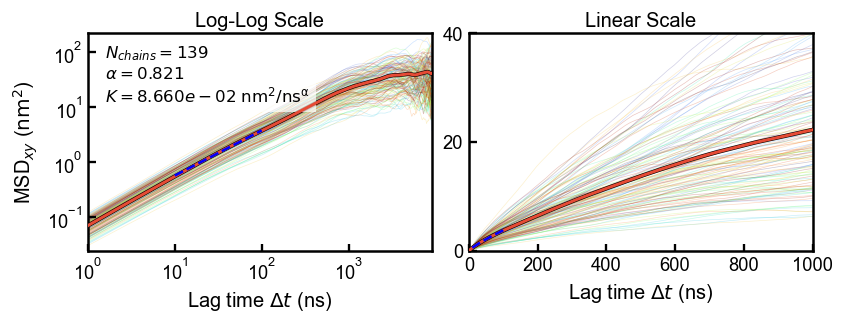

[缓存] 读取 A^2/ns 原始缓存: HELIX_SOLV_xy_msd_data.npz
[绘图] HELIX_SOLV_xy_msd_nm_ns.png


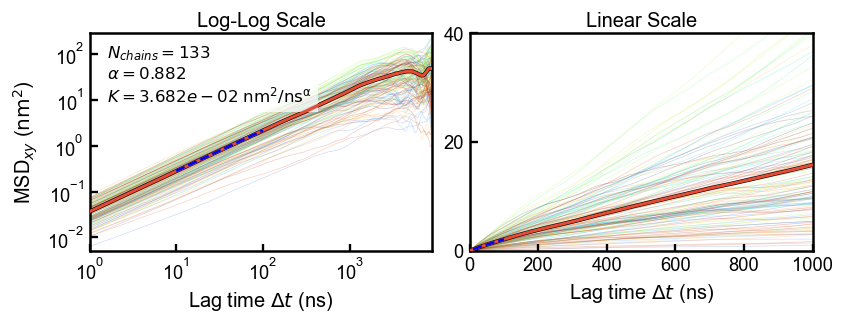

[缓存] 读取 A^2/ns 原始缓存: IDP_MEM_xy_msd_data.npz
[绘图] IDP_MEM_xy_msd_nm_ns.png


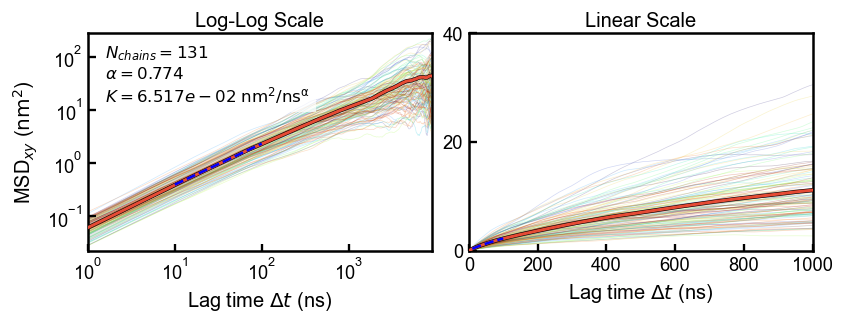

[缓存] 读取 A^2/ns 原始缓存: HELIX_MEM_xy_msd_data.npz
[绘图] HELIX_MEM_xy_msd_nm_ns.png


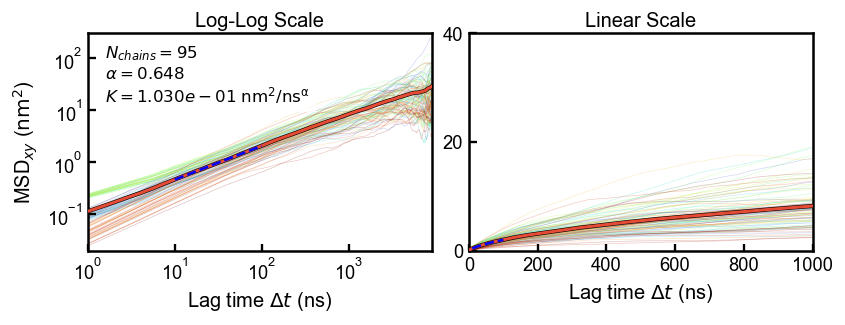

有效链数统计:
$\text{IDP}_{50}$: N = 139
$\text{Hel}_{50}$: N = 133
$\text{IDP}_{50}$-Mem: N = 131
$\text{Hel}_{10}\text{IDP}_{40}$-Mem: N = 95
[绘图] combined_xy_msd_average_log_nm_ns.png
[绘图] combined_xy_msd_average_linear_nm_ns.png


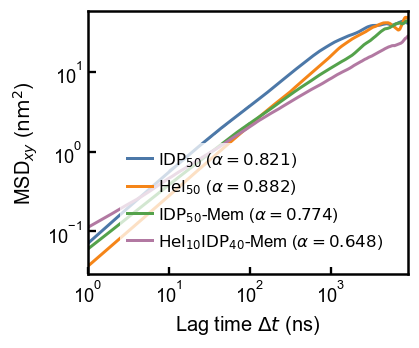

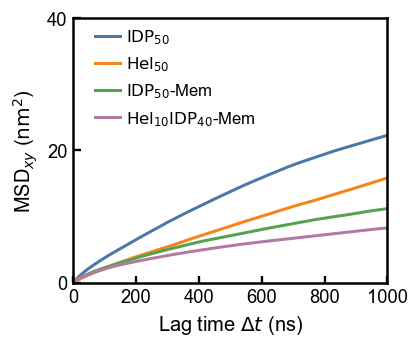


输出文件夹: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/MSD/MSD_each/MSD_xy_results
数据文件:
 - IDP_SOLV_xy_msd_nm_ns_data.npz
 - IDP_SOLV_xy_msd_nm_ns_average.csv
 - IDP_SOLV_xy_msd_nm_ns_fit.txt
 - HELIX_SOLV_xy_msd_nm_ns_data.npz
 - HELIX_SOLV_xy_msd_nm_ns_average.csv
 - HELIX_SOLV_xy_msd_nm_ns_fit.txt
 - IDP_MEM_xy_msd_nm_ns_data.npz
 - IDP_MEM_xy_msd_nm_ns_average.csv
 - IDP_MEM_xy_msd_nm_ns_fit.txt
 - HELIX_MEM_xy_msd_nm_ns_data.npz
 - HELIX_MEM_xy_msd_nm_ns_average.csv
 - HELIX_MEM_xy_msd_nm_ns_fit.txt
图片文件:
 - IDP_SOLV_xy_msd_nm_ns.png
 - HELIX_SOLV_xy_msd_nm_ns.png
 - IDP_MEM_xy_msd_nm_ns.png
 - HELIX_MEM_xy_msd_nm_ns.png
 - combined_xy_msd_average_log_nm_ns.png
 - combined_xy_msd_average_linear_nm_ns.png


In [15]:
# ===================== 主流程：有缓存直接画；无缓存先算再画 =====================
RESULTS = []
PLOT_FILES = []

for dataset in DATASETS:
    result = analyze_dataset(dataset)
    RESULTS.append(result)
    PLOT_FILES.append(plot_dataset_result(dataset, result))

print("有效链数统计:")
for dataset, result in zip(DATASETS, RESULTS):
    print(f"{dataset['title']}: N = {result['msd_matrix_nm2'].shape[1]}")

COMBINED_PLOTS = plot_combined_average(DATASETS, RESULTS)

print("\n输出文件夹:", OUTPUT_DIR)
print("数据文件:")
for dataset, result in zip(DATASETS, RESULTS):
    print(" -", result["converted_cache_file"].name)
    print(" -", result["csv_file"].name)
    print(" -", result["fit_file"].name)
print("图片文件:")
for plot_file in PLOT_FILES + COMBINED_PLOTS:
    print(" -", plot_file.name)
